In [1]:
import skeliner as sk

In [2]:
mesh = sk.io.load_mesh("./data/720575940573924400.obj")

You don't need me to tell you that the meshes we download from CAVEClient/CloudVolume have quite a few problems.

First of all, they are formed by a bunch of marching cubes. 

![](./assets/marching_cubes.png)

which means at the boundaries of each pair of cubes, anomalies can occur, which includes:

1. edges should be connected but do not (gaps, parallel patches)
2. edges should not be connected but do (different type of parallel patches, fusions)

There are also other problems not related to the cube merging failures, but we might want to find them or clean them up before skeletonization: 

1. organelles (mitochondria, microtubes, ERs, etc), which often contributes to phantom branches
2. soma/nuclues, which is a nice starting anchor for initialize the skeletonization;
3. all dendiritic loops due to fusions should be removed in the mesh, all disconnected components due to other anomolies other than cube merging failures (the reason, I suspect, is different cells fighting for the same vertices) should be reconnected

In `skeliner.pre` module, we provides a handful of functions to repair the mesh (to a certain degree), so that we might get better skeletons later.



### Parallels 

![parallels](./assets/parallels.png)

In [3]:
# 1. Parallel patches
patches = sk.pre.find_parallel_patches(mesh, verbose=True)
if patches:
    mesh = sk.pre.remove_parallel_patches(mesh, patches=patches, verbose=True)

[skeliner.pre] Finding parallel patches …
[skeliner.pre] Parallel patches: 36 patches, 527 faces (X:12, Y:4, Z:20) at 59 boundaries (7.8s)
[skeliner.pre] Removing parallel patches …
[skeliner.pre] remove_parallel_patches: removed 369f (0 fold + 36 parallel); trimmed to overlap 527→369f; +295f stitched (17.4s)


### Organelles

![](./assets/organelles.png)

In [4]:
# 2. Organelles
organelles, mesh_stats = sk.pre.find_organelles(mesh, return_mesh_stats=True, verbose=True)

[skeliner.pre] Finding organelles …
[skeliner.pre] Computing mesh stats …
[skeliner.pre] Mesh stats: 656 components, radius=535, raw internal=370,414 (20.9%) (30.2s)
[skeliner.pre] Finding isolated organelles …
[skeliner.pre] Isolated organelles: 614 fragments, 94,544 faces (41 external kept; 569 by dots, 86 by geometry) (0.6s)
[skeliner.pre] Finding pocket organelles …
[skeliner.pre] Pocket organelles: 241,907 faces from 605 mouths (fill 211,279, bridge +3, holes +33,841, rejected 107) (7.6s)
[skeliner.pre] find_organelles: pocket=243,125, isolated=94,544, 32 structural components, enclosed +1,218 (42.4s)


### Soma

[skeliner.pre] Finding soma …
[skeliner.pre] Soma: nucleus=[844988, 474792, 26460] r=3311 z=[24150–28770]; ellipsoid axes=[6077, 5259, 4457], 55,437 verts, cutoff ring 40/1354 (21.5s)


(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

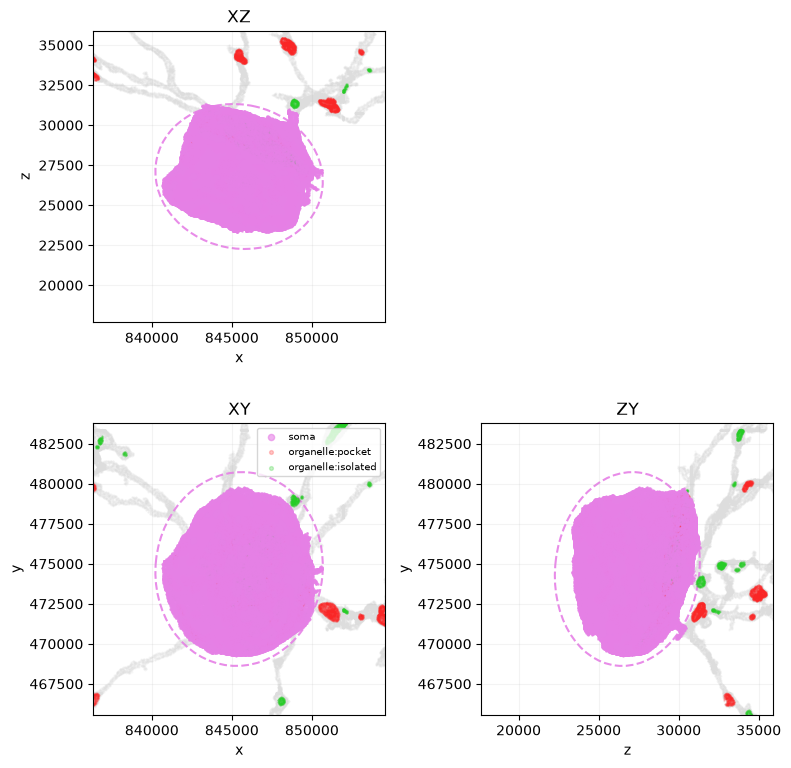

In [5]:
# 3. Soma
soma = sk.pre.find_soma_via_ring_cutoff(mesh, organelles=organelles, mesh_stats=mesh_stats, verbose=True)
sk.plot.vis2d.diagnose_soma(mesh=mesh, soma=soma, organelles=organelles, figsize=(8,8))

### Bridging and unbridging

In [6]:
# 4. Fusions → Disconnected → gaps
fusions = sk.pre.find_fusions(mesh, mesh_stats=mesh_stats, verbose=True)

disconnected = sk.pre.find_disconnected(mesh, soma=soma, organelles=organelles, fusions=fusions, mesh_stats=mesh_stats, verbose=True)

gaps = sk.pre.find_gaps(mesh, soma=soma, disconnected=disconnected, fusions=fusions, mesh_stats=mesh_stats, verbose=True)
if gaps:
    mesh = sk.pre.remove_gaps(mesh, gaps=gaps, mesh_stats=mesh_stats, verbose=True)

[skeliner.pre] Finding fusions …
[skeliner.pre] Fusions: 74 regions, 646 boundary faces (15.6s)
[skeliner.pre] Finding disconnected components …
[skeliner.pre] Disconnected: 31 of 677 non-main components, 44,844 faces; excluded 1 soma+531 organelle (8.0s)
[skeliner.pre] Finding gaps …
[skeliner.pre] Gaps: 31 gaps across 31 disconnected components, dist 0–720 (24.1s)
[skeliner.pre] Removing gaps …
[skeliner.pre] remove_gaps: bridged 29/31 gaps, removed 828f, stitched +2,664f, 2 skipped (92.5s)


In [7]:
# 5. Remove fusions
if fusions:
    mesh = sk.pre.remove_fusions(mesh, fusions=fusions, mesh_stats=mesh_stats, verbose=True)

[skeliner.pre] Removing fusions …
[skeliner.pre] remove_fusions: removed 620f, split 96 fan vertices (4.8s)


### The Last Step

In [8]:
# 6. Break up mesh
if soma is not None:
    components = sk.pre.break_up_mesh(mesh, soma, organelles, verbose=True)

[skeliner.pre] Breaking up mesh …
[skeliner.pre] break_up_mesh: 4 neurites, 13 discarded (48f), trapped +11f, soma +467f (6.0s)


In [ ]:
# 7. Optional Mesh Compaction (remove degenerated faces and reindex everything, 
#    not truly necessary if you want to keep the original mesh indices, but highly recommended)
# mesh, components = sk.pre.compact_mesh(mesh, components=components, verbose=True)

### One call to rule them all

In [10]:
# run the entire pipeline in one call:
mesh, components = sk.preprocess(mesh, compact=True, verbose=True)

[skeliner.pre] starting preprocessing (887,722 vertices, 1,775,006 faces)
 ↳  find & remove parallel patches               … 62.93 s
 ↳  find organelles                              … 43.60 s
      └─ pocket=255,921, isolated=94,712
 ↳  find soma                                    … 20.49 s
      └─ center=[845453.0, 474676.0, 26792.0]
 ↳  find fusions                                 … 14.40 s
      └─ 24 fusions
 ↳  find disconnected                            … 7.62 s
      └─ 4 disconnected components
 ↳  find & remove gaps                           … 26.99 s
      └─ 2 gaps
 ↳  remove fusions                               … 4.99 s
 ↳  break up mesh                                … 6.07 s
      └─ 4 neurites
 ↳  compact mesh                                 … 0.21 s
[skeliner.pre] preprocessing done (1,773,151 faces, 187.3s)


(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

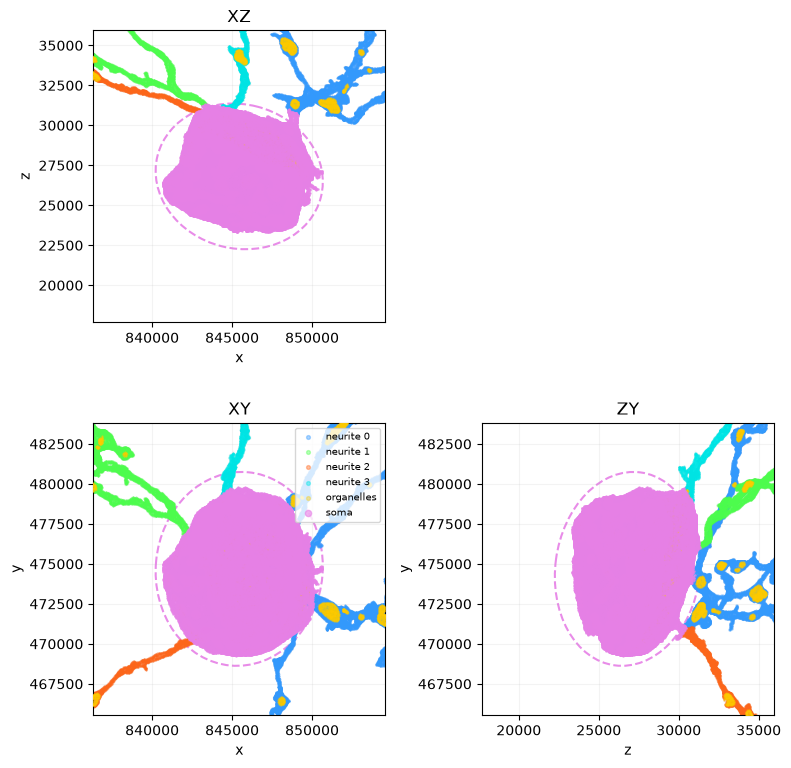

In [11]:
sk.plot.vis2d.diagnose_components(mesh=mesh, components=components, figsize=(8,8))

In [12]:
# # save mesh and components
sk.io.save_mesh(mesh=mesh, path="./data/mesh_cleaned.obj")
sk.io.save_components(components, path="./data/components.npz")

### Bonus: mesh viewer

In [ ]:
# sk.plot.view(port=8888)


Skeliner Viewer
  URL:          http://127.0.0.1:8888
  State file:   /tmp/skeliner_view/8888/state.json
  Annotations:  /tmp/skeliner_view/8888/annotations.json
  Camera cmd:   /tmp/skeliner_view/8888/camera.json

  Viewer running in background. Call sk.plot.stop_viewer() to stop.


In [ ]:
# sk.plot.stop_viewer()

In [15]:
%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark

Last updated: 2026-08-06 14:02:53 CEST

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.15.0

skeliner: 0.3.0

Watermark: 2.6.0



ERROR:    [Errno 48] error while attempting to bind on address ('127.0.0.1', 8888): address already in use
